In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ct_path = "../data/sample_ct.nii.gz"
ct_scan = nib.load(ct_path)
ct_data = ct_scan.get_fdata()
print(ct_data.shape)

(272, 272, 240)


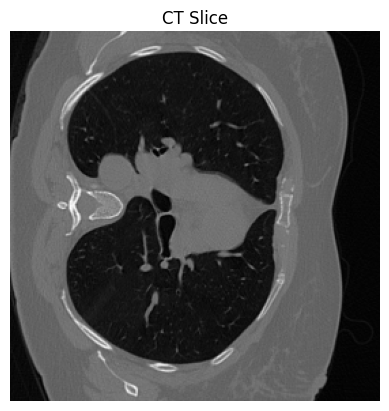

In [3]:
slice_index = 150

plt.imshow(ct_data[:, :, slice_index], cmap="gray")
plt.title("CT Slice")
plt.axis("off")
plt.show()

In [4]:
ct_path = "../data/sample_ct.nii.gz"
mask_path = "../data/lung_mask.nii.gz"

In [5]:
import numpy as np

# 创建一个假的mask
mask_data = np.zeros_like(ct_data)

# 在中心区域生成“病灶”
mask_data[200:300, 200:300, 100:150] = 1

print(mask_data.shape)

(272, 272, 240)


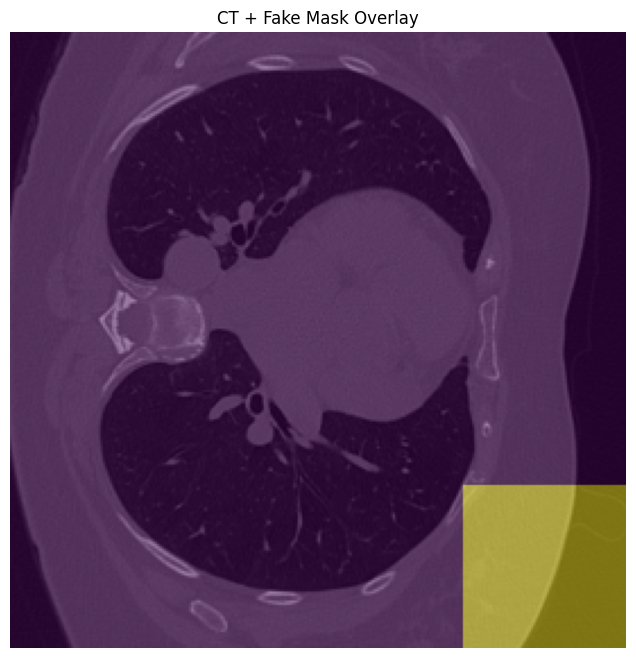

In [6]:
slice_index = 120

plt.figure(figsize=(8,8))

plt.imshow(ct_data[:, :, slice_index], cmap="gray")

plt.imshow(mask_data[:, :, slice_index], alpha=0.5)

plt.title("CT + Fake Mask Overlay")

plt.axis("off")

plt.show()

In [7]:
from monai.transforms import (
    Compose,
    EnsureChannelFirst,
    ScaleIntensity,
    Resize
)

In [8]:
transform = Compose([
    EnsureChannelFirst(channel_dim="no_channel"),
    ScaleIntensity(),
    Resize((128, 128, 64))
])

In [9]:
processed_ct = transform(ct_data)

print(processed_ct.shape)


torch.Size([1, 128, 128, 64])


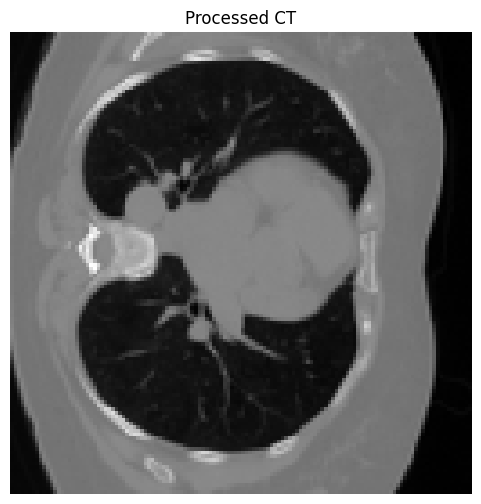

In [10]:
slice_index = 32

plt.figure(figsize=(6,6))

plt.imshow(processed_ct[0, :, :, slice_index], cmap="gray")

plt.title("Processed CT")

plt.axis("off")

plt.show()

In [11]:
from monai.data import Dataset, DataLoader

In [12]:
data_dicts = [
    {
        "image": ct_data,
        "label": mask_data
    }
]

In [13]:
dataset = Dataset(
    data=data_dicts,
    transform=None
)

In [14]:
dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

In [15]:
for batch in dataloader:
    image = batch["image"]
    label = batch["label"]

    print("Image shape:", image.shape)
    print("Label shape:", label.shape)

    break

Image shape: torch.Size([1, 272, 272, 240])
Label shape: torch.Size([1, 272, 272, 240])


In [16]:
from monai.transforms import Compose, Lambda

transform = Compose([
    Lambda(lambda x: {
        "image": processed_ct,
        "label": mask_data
    })
])

In [17]:
dataset = Dataset(
    data=data_dicts,
    transform=transform
)

In [18]:
for batch in dataloader:
    image = batch["image"]
    label = batch["label"]

    print(image.shape)
    print(label.shape)

    break

torch.Size([1, 272, 272, 240])
torch.Size([1, 272, 272, 240])


In [19]:
from monai.networks.nets import UNet
import torch

In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [23]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,   # 3D
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2
).to(device)

In [25]:
import torch.nn as nn
import torch.optim as optim

loss_function = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [26]:
num_epochs = 5

model.train()

for epoch in range(num_epochs):

    epoch_loss = 0

    for batch in dataloader:

        images = batch["image"].float().to(device)
        labels = batch["label"].float().to(device)

        # 增加 channel 维度
        images = images.unsqueeze(1)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.7660
Epoch 2, Loss: 0.7451
Epoch 3, Loss: 0.7371
Epoch 4, Loss: 0.7335
Epoch 5, Loss: 0.7267


In [27]:
for batch in dataloader:

    images = batch["image"]
    labels = batch["label"]

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

    break

Image shape: torch.Size([1, 272, 272, 240])
Label shape: torch.Size([1, 272, 272, 240])


In [28]:
for batch in dataloader:

    images = batch["image"].float()
    labels = batch["label"].float()

    images = images.unsqueeze(1)
    labels = labels.unsqueeze(1)

    print(images.shape)
    print(labels.shape)

    break

torch.Size([1, 1, 272, 272, 240])
torch.Size([1, 1, 272, 272, 240])


In [29]:
images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([1, 1, 272, 272, 240])


In [30]:
import torch.nn as nn

loss_function = nn.BCEWithLogitsLoss()

In [31]:
labels = labels.to(device)

loss = loss_function(outputs, labels)

print(loss.item())

0.7190566062927246


In [32]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [33]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed!")

One training step completed!


In [34]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [35]:
optimizer.zero_grad()

outputs = model(images)

loss = loss_function(outputs, labels)

loss.backward()

optimizer.step()

print("Training step completed")
print("Loss:", loss.item())

Training step completed
Loss: 0.712822675704956


In [37]:
for epoch in range(10):

    optimizer.zero_grad()

    outputs = model(images)

    loss = loss_function(outputs, labels)

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.7116507291793823
Epoch 2, Loss: 0.7106250524520874
Epoch 3, Loss: 0.7097401022911072
Epoch 4, Loss: 0.708983302116394
Epoch 5, Loss: 0.7083331942558289
Epoch 6, Loss: 0.7077586650848389
Epoch 7, Loss: 0.7072238326072693
Epoch 8, Loss: 0.7066971063613892
Epoch 9, Loss: 0.7061575055122375
Epoch 10, Loss: 0.7055959105491638


In [38]:
from monai.metrics import DiceMetric

In [39]:
dice_metric = DiceMetric(
    include_background=True,
    reduction="mean"
)

In [40]:
preds = torch.sigmoid(outputs)

preds = (preds > 0.5).float()

dice_metric(y_pred=preds, y=labels)

dice_score = dice_metric.aggregate().item()

print("Dice Score:", dice_score)

Dice Score: 0.029814107343554497


In [41]:
model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUn

In [42]:
with torch.no_grad():

    outputs = model(images)

    preds = torch.sigmoid(outputs)

    preds = (preds > 0.5).float()

In [43]:
ct_np = images.cpu().numpy()

label_np = labels.cpu().numpy()

pred_np = preds.cpu().numpy()

In [44]:
slice_index = 120

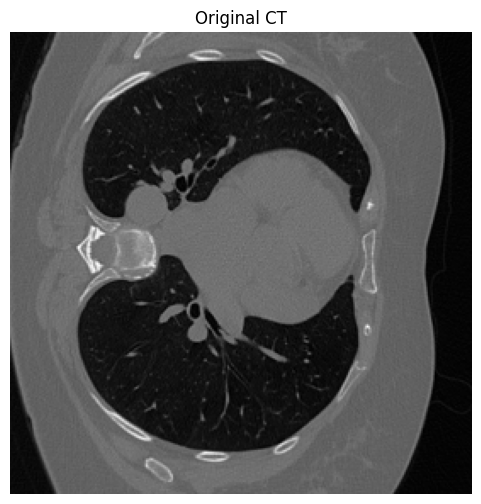

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(
    ct_np[0,0,:,:,slice_index],
    cmap="gray"
)

plt.title("Original CT")

plt.axis("off")

plt.show()

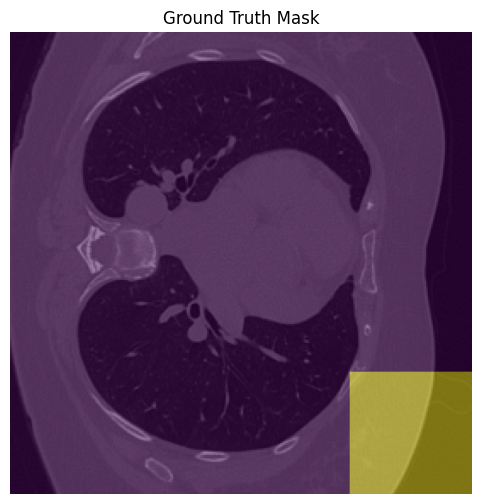

In [46]:
plt.figure(figsize=(6,6))

plt.imshow(
    ct_np[0,0,:,:,slice_index],
    cmap="gray"
)

plt.imshow(
    label_np[0,0,:,:,slice_index],
    alpha=0.5
)

plt.title("Ground Truth Mask")

plt.axis("off")

plt.show()

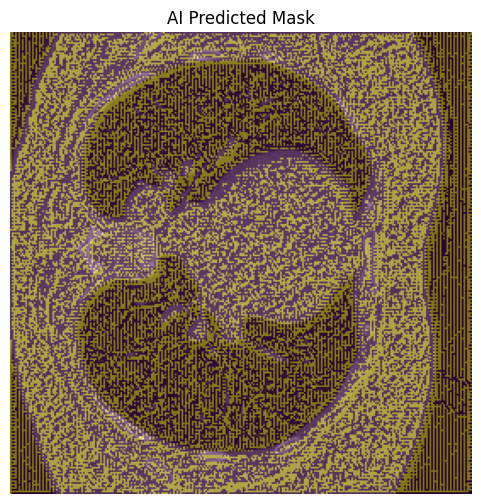

In [47]:
plt.figure(figsize=(6,6))

plt.imshow(
    ct_np[0,0,:,:,slice_index],
    cmap="gray"
)

plt.imshow(
    pred_np[0,0,:,:,slice_index],
    alpha=0.5
)

plt.title("AI Predicted Mask")

plt.axis("off")

plt.show()

In [49]:
torch.save(
    model.state_dict(),
    "lung_ct_unet.pth"
)

print("Model saved!")

Model saved!


In [50]:
model.load_state_dict(
    torch.load("lung_ct_unet.pth")
)

model.eval()

print("Model loaded!")

Model loaded!
